In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Way 1: From Scratch

Slope: 8.14
Intercept: 33.10
Equation score: 33.10 + 8.14 x hours

Prediction for 6 hours: 81.9


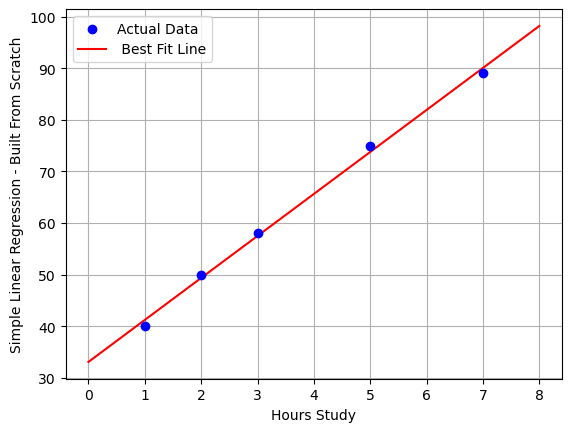

In [2]:
# our data
hours = np.array([1, 2, 3, 5, 7])
scores = np.array([40, 50, 58, 75, 89])

# Step 1: Calculate means
x_mean = np.mean(hours)
y_mean = np.mean(scores)

# Step 2: Calculate theta_1 (slope)
numerator = np.sum((hours - x_mean) * (scores - y_mean))
denominator = np.sum((hours - x_mean) ** 2)

theta_1 = numerator / denominator

# Step 3: Calculate theta_0 (intercept)
theta_0 = y_mean - theta_1 * x_mean

print("=" * 60)
print(f"Slope: {theta_1:.2f}")
print(f"Intercept: {theta_0:.2f}")
print(f"Equation score: {theta_0:.2f} + {theta_1:.2f} x hours")

# Step 4: Predict
def predict(x):
    return theta_0 + theta_1 * x


print(f"\nPrediction for 6 hours: {predict(6):.1f}")

# Step 5: Visualization
x_line = np.linspace(0, 8, 100)
plt.scatter(hours, scores, color = 'blue', label = 'Actual Data', zorder = 5)
plt.plot(x_line, predict(x_line), color = 'red', label = ' Best Fit Line')
plt.xlabel('Hours Study')
plt.ylabel('Simple Linear Regression - Built From Scratch')
plt.legend()

plt.grid(True)
plt.show()


# Way 2: Using Sci-kit Learn

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

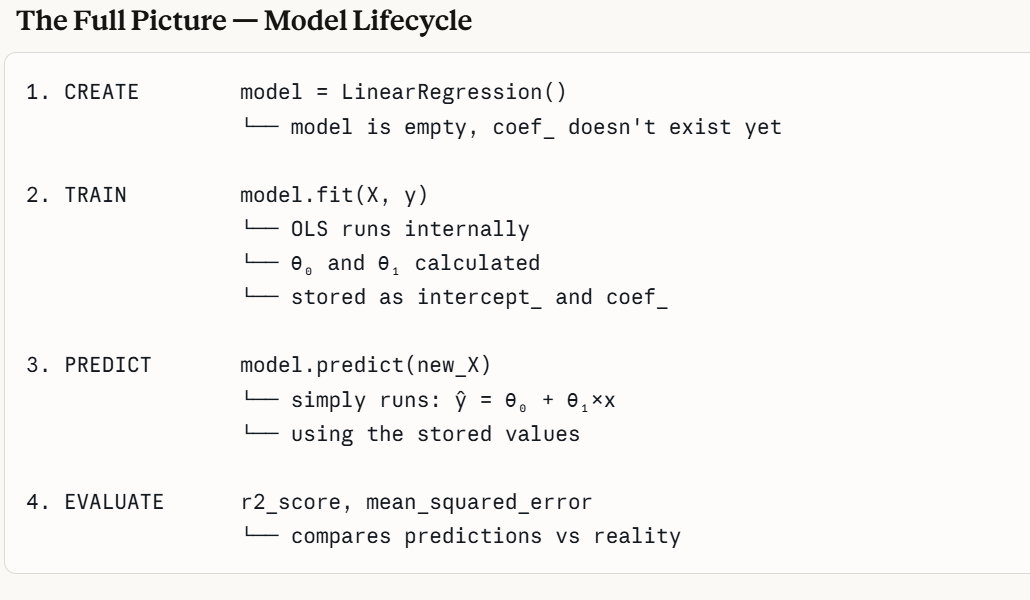

In [9]:
# Data must be 2D for sklearn
hours = np.array([1, 2, 3, 5,7]).reshape(-1, 1) # X is always a table - row = samples, columns = features 
scores = np.array([40, 50, 58, 75, 89]) # Y is always a list - one value per sample

# Train the model
model = LinearRegression() # Empty machine
model.fit(hours, scores) # THis where learning happens

# Parameters
print(f"Slope: {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

# Prediction
predictions = model.predict(hours)
sk_predict = model.predict([[6]])

# Evaluate
mse = mean_squared_error(scores, predictions)
r2 = r2_score(scores , predictions)

print(f"MSE: {mse:.2f}")
print(f"R Squared: {r2:.4f}")

predictions
sk_predict

Slope: 8.14
Intercept: 33.10
MSE: 0.95
R Squared: 0.9969


array([81.93103448])

# 📘 Session 01 — Simple Linear Regression
### *Data Science & Machine Learning — Personal Study Notes*
---
> **"Math without code is philosophy. Code without math is guessing. You need both — in the right order."**

---

## 📌 Table of Contents
1. [What Is Simple Linear Regression?](#1-what-is-simple-linear-regression)
2. [The Math Behind It](#2-the-math-behind-it)
3. [The Loss Function — MSE](#3-the-loss-function--mse)
4. [OLS — How Parameters Are Calculated](#4-ols--how-parameters-are-calculated)
5. [The R² Score](#5-the-r-score)
6. [Code — From Scratch](#6-code--from-scratch)
7. [Code — Using Scikit-Learn](#7-code--using-scikit-learn)
8. [What Lives Inside a Trained Model](#8-what-lives-inside-a-trained-model)
9. [Failure Cases](#9-failure-cases)
10. [Key Debugging Lessons](#10-key-debugging-lessons)
11. [Summary Cheatsheet](#11-summary-cheatsheet)

---

## 1. What Is Simple Linear Regression?

**Simple Linear Regression** finds the **single best straight line** through your data that minimizes prediction error.

### Intuition First
Given data like this:

| Hours Studied | Exam Score |
|---|---|
| 1 | 40 |
| 2 | 50 |
| 3 | 58 |
| 5 | 75 |
| 7 | 89 |

Your brain instantly sees the pattern — *more hours → higher score.*
If someone studied **6 hours**, you could guess their score even though it's not in the table.

> ✅ **That guess — that line your brain draws — IS Simple Linear Regression.**

### When To Use It
- You have **one input feature** (x) and **one output** (y)
- The relationship between x and y appears **linear** (straight line)
- You want to **predict** a continuous numerical value

---

## 2. The Math Behind It

### The Line Equation

From school:
$$y = mx + c$$

In ML notation:
$$\hat{y} = \theta_0 + \theta_1 x$$

| Symbol | Name | Plain English |
|---|---|---|
| $\hat{y}$ | Predicted output | The score we're guessing |
| $x$ | Input feature | Hours studied |
| $\theta_1$ | Slope / Weight | Score increase *per extra hour* |
| $\theta_0$ | Intercept / Bias | Base score even at 0 hours |

> 💡 **Your school math is already ML math.** Nothing new — just new notation.

---

## 3. The Loss Function — MSE

### What Is "Error"?
The distance between the **real value** and the **predicted value**:
$$\text{error} = y - \hat{y}$$

### Why We Square It
- Raw errors cancel out (positives + negatives = 0)
- Squaring makes all errors positive
- Squaring also **penalizes large errors more** than small ones

### Mean Squared Error (MSE)
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

> ✅ **The best line = the line that produces the smallest MSE.**
> Finding that line is called **Ordinary Least Squares (OLS).**

---

## 4. OLS — How Parameters Are Calculated

OLS solves for θ₀ and θ₁ **analytically** — no guessing, one exact solution:

$$\theta_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}$$

$$\theta_0 = \bar{y} - \theta_1 \bar{x}$$

### Plain English Translation
| Part | What It Means |
|---|---|
| **Numerator of θ₁** | How much x and y *move together* (covariance) |
| **Denominator of θ₁** | How much x varies on its own (variance) |
| **θ₀ formula** | Shifts the line to pass through the center point $(\bar{x}, \bar{y})$ |

---

## 5. The R² Score

MSE tells you the raw error. **R²** tells you *how good* your model is — in percentage terms.

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

| R² Value | Meaning |
|---|---|
| **1.0** | Perfect — model explains 100% of variation |
| **0.85+** | Strong model |
| **0.50–0.84** | Moderate — something important is missing |
| **< 0.50** | Weak model |
| **0 or negative** | Worse than just predicting the mean every time |

> 💡 **R² answers: "How much of the variation in y does my model explain?"**

---



## 6. What Lives Inside a Trained Model

```python
# Inspect everything stored inside the model
print(model.__dict__)
```

| Attribute | What It Is | Example |
|---|---|---|
| `model.coef_` | Array of slopes — **one per feature** | `array([7.39])` |
| `model.intercept_` | The bias/intercept θ₀ | `34.26` |
| `model.n_features_in_` | Number of features used to train | `1` |
| `model.fit_intercept` | Whether θ₀ was calculated | `True` |

### The Model Lifecycle

```
1. CREATE     model = LinearRegression()
              └── Empty — coef_ doesn't exist yet

2. TRAIN      model.fit(X, y)
              └── OLS runs internally
              └── θ₀ → stored as model.intercept_
              └── θ₁ → stored as model.coef_

3. PREDICT    model.predict(new_X)
              └── Runs: ŷ = θ₀ + θ₁ × x using stored values

4. EVALUATE   r2_score, mean_squared_error
              └── Compares predictions vs reality
```

### Why `coef_` Is an Array

```python
# Simple regression — 1 feature
model.coef_      # → array([7.39])    ← still an array
model.coef_[0]   # → 7.39            ← index to get the number

# Multiple regression — 3 features (preview of Session 2)
model.coef_      # → array([7.39, 2.1, 0.85])
#                          hours  sleep  prev_grade
```

> ✅ **Rule:** `coef_` is always an array. `intercept_` is always a single number.

### Data Shape Rule (Critical for sklearn)

| Variable | Role | Required Shape | Why |
|---|---|---|---|
| `X` (features) | Input | **2D** `(n_samples, n_features)` | sklearn expects a table — even with 1 feature |
| `y` (target) | Output | **1D** `(n_samples,)` | Always only one target value |

```python
X.reshape(-1, 1)
# -1 → "figure out rows automatically"
#  1 → "I want exactly 1 column"
```

---

## 7. Failure Cases

> ⚠️ **Knowing when a model breaks is what separates experts from beginners.**

| Failure Case | What Happens | How to Detect |
|---|---|---|
| **Non-linear relationship** | Line can't capture curves → bad predictions | Plot residuals, look for patterns |
| **Outliers** | One extreme point pulls the entire line | Always visualize before modeling |
| **No real relationship** | You're fitting noise, not signal | R² near 0, p-value > 0.05 |
| **Extrapolation** | Unreliable predictions outside data range | Never trust predictions far beyond your data |
| **Multicollinearity** | N/A for simple regression | Relevant in Multiple Regression (Session 2) |

### Expert Diagnostic Questions for Every Model
1. *What problem is this model solving?*
2. *When does it break?*
3. *How would I explain it in one sentence?*

---


> 💡 **Golden Rule: Define your data once at the top of every notebook. Never retype it.**

### 🎨 Clean Plot Labels
```python
# ❌ Wrong
plt.ylabel('Simple Linear Regression - Built From Scratch')  # this is a title, not a label

# ✅ Correct
plt.ylabel('Exam Score')
plt.title('Simple Linear Regression — Built From Scratch')
```

---

## 8. Summary Cheatsheet

| Concept | One-Line Definition |
|---|---|
| **Simple Linear Regression** | Best straight line through data that minimizes prediction error |
| **θ₁ (Slope)** | How much y increases for every 1 unit increase in x |
| **θ₀ (Intercept)** | Value of y when x = 0 |
| **MSE** | Average squared distance between predictions and actual values |
| **OLS** | Analytical method to find the exact best θ₀ and θ₁ |
| **R²** | Percentage of variation in y explained by the model (0 to 1) |
| **model.fit()** | Calculate and memorize θ₀ and θ₁ |
| **model.predict()** | Use memorized parameters to compute ŷ = θ₀ + θ₁x |

### The 4-Step Learning Framework (Used Every Session)
```
1. INTUITION    → What is it trying to do?
2. MATH         → Why does the formula look like that?
3. CODE         → How do we build and use it?
4. FAILURE      → When does it break and why?
```

---

## 📝 Homework

- [x] Run from-scratch code in Jupyter
- [x] Run sklearn code in Jupyter
- [x] Verify manual vs sklearn predictions match
- [ ] Add an extreme outlier — observe how R² changes
- [ ] Answer: *"What would happen if the relationship was curved, not straight?"*

---

*Next Session → **Multiple Linear Regression** — more features, same core idea, new challenges.*

---
*Session 01 | Simple Linear Regression | Personal DS/ML Study Notes*
